In [ ]:
# ── MLOps bootstrap (auto-injected by inject_mlops_cell.py) ──────────────────
import os, warnings, mlflow
warnings.filterwarnings("ignore")

SEED = 42
import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)
try:
    import torch; torch.manual_seed(SEED)
except ImportError:
    pass
try:
    import tensorflow as tf; tf.random.set_seed(SEED)
except ImportError:
    pass

_nb_name = os.path.basename(os.path.abspath("__file__") if "__file__" in dir() else ".").replace(".ipynb","")
mlflow.set_tracking_uri("sqlite:///" + str(Path(__file__).parent.parent.parent / "mlflow.db")
                        if "__file__" in dir() else "sqlite:///mlflow.db")
_exp = mlflow.set_experiment(_nb_name or "unnamed_notebook")
print(f"MLflow experiment: {_exp.name}")


# Table of contents
>[Data](#scrollTo=1ec9484b)

>>[Reading Data](#scrollTo=8897cf7a)

>>[Data Info](#scrollTo=9ebbe638)

>>[Unique Artists](#scrollTo=b2c166cc)

>>[Average Popularity](#scrollTo=285c142a)

>>[Most Popular Track](#scrollTo=ab8ec058)

>[Visualization](#scrollTo=8e15ef31)

>>[Popularity Distribution](#scrollTo=03a01494)

>>[Genre Counts](#scrollTo=46191c68)

>>[Distribution of Popularity](#scrollTo=a5342c7d)

>>[Danceability vs Energy](#scrollTo=7ef4254e)

>>[Key Counts](#scrollTo=116ea7a8)

>>[Top Danceability by Genre](#scrollTo=b2fac0b9)

>>[Top Energy by Genre](#scrollTo=72b62d7f)

>[Clustering Using K Means](#scrollTo=e36855f7)

>>[Clustered Genres](#scrollTo=cecbd0eb)

>[Top Listened Genres](#scrollTo=915dd7cc)

>>[Top Least Listened Genres](#scrollTo=c2c2eb40)

>>[Top Genres with both Energy and Danceability](#scrollTo=28625767)

>>[Top Artist by genre](#scrollTo=dd85d69c)

>>[Top Songs by Tempo](#scrollTo=e23242f2)

>>[Songs by Instrumentalness](#scrollTo=8fc78f06)

>>[Top Genres by Acouticness](#scrollTo=e6249b0a)

>>[Top Genres by Speechness](#scrollTo=7e29b007)

>>[Top Genres by Loudness](#scrollTo=385bbe94)



Importing necessary libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os

# Data

## Reading Data

Reading data from CSV file


In [ ]:
import pandas as pd
import os

# --- Schema Reconciliation: load from centralized data directory ---
_data_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "..", "data", "spotify_health_clustering")
_csv_path = os.path.join(_data_dir, "train.csv") if os.path.exists(os.path.join(_data_dir, "train.csv")) else "data.csv"
df = pd.read_csv(_csv_path)

# Column mapping: substitute dataset uses different column names
_col_map = {"artists": "artist_name", "track_genre": "genre"}
df = df.rename(columns={k: v for k, v in _col_map.items() if k in df.columns})
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Validation
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
df.head()

## Data Info

Printing the name of columns and the first five rows of data frame

In [3]:
print(df.columns)
print(df.head())

Index(['Unnamed: 0', 'artist_name', 'track_name', 'track_id', 'popularity',
       'year', 'genre', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature'],
      dtype='object')
   Unnamed: 0    artist_name        track_name                track_id  \
0           0     Jason Mraz   I Won't Give Up  53QF56cjZA9RTuuMZDrSA6   
1           1     Jason Mraz  93 Million Miles  1s8tP3jP4GZcyHDsjvw218   
2           2  Joshua Hyslop  Do Not Let Me Go  7BRCa8MPiyuvr2VU3O9W0F   
3           3   Boyce Avenue          Fast Car  63wsZUhUZLlh1OsyrZq7sz   
4           4   Andrew Belle  Sky's Still Blue  6nXIYClvJAfi6ujLiKqEq8   

   popularity  year     genre  danceability  energy  key  loudness  mode  \
0          68  2012  acoustic         0.483   0.303    4   -10.058     1   
1          50  2012  acoustic         0.572   0.454    3   -10.286     1   
2          57  2012  

## Unique Artists

The code calculates the number of unique artists in the "artist_name" column of a dataframe and prints the result. It provides the count of distinct artists in the dataset.






In [5]:
unique_artists = df['artist_name'].nunique()
print("Number of unique artists:", unique_artists)

Number of unique artists: 64159


## Average Popularity

The code calculates the average popularity value from the "popularity" column of a dataframe and prints the result. It provides the mean popularity value across all entries in the dataset.






In [6]:
average_popularity = df['popularity'].mean()
print("Average popularity:", average_popularity)

Average popularity: 18.38312277325387


## Most Popular Track

The code finds the maximum popularity value in the "popularity" column of a dataframe and identifies the track with the highest popularity. It then prints the track name and artist name of the most popular track.



In [7]:
max_popularity = df['popularity'].max()
max_popularity_track = df[df['popularity'] == max_popularity][['track_name', 'artist_name']]
print("Max popularity track:")
print(max_popularity_track)

Max popularity track:
       track_name  artist_name
612503    Flowers  Miley Cyrus


# Visualization

## Popularity Distribution

The code creates a histogram of the "popularity" column in the dataframe, with 20 bins. It visualizes the distribution of popularity values in the dataset.






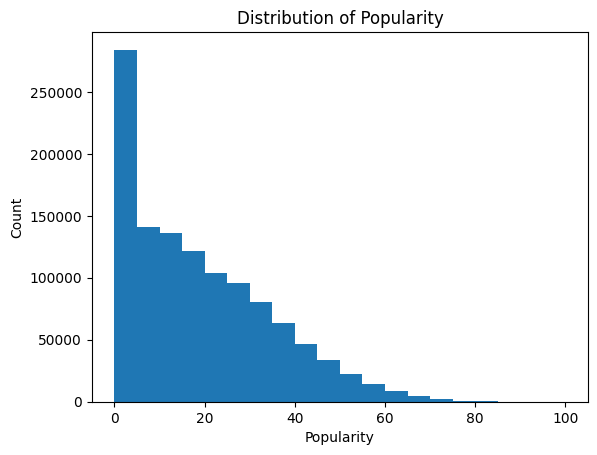

In [8]:
import matplotlib.pyplot as plt

plt.hist(df['popularity'], bins=20)
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.title('Distribution of Popularity')
plt.show()

The code counts the number of occurrences of each unique value in the "genre" column of the dataframe and prints the counts for each genre. It provides an overview of the frequency of different genres in the dataset.






In [9]:
genre_counts = df['genre'].value_counts()
print("Genre counts:")
print(genre_counts)

Genre counts:
black-metal       21852
gospel            21621
ambient           21389
acoustic          21097
alt-rock          20918
                  ...  
chicago-house      5170
dubstep            4774
detroit-techno     3920
rock               3319
songwriter          589
Name: genre, Length: 82, dtype: int64


The code calculates the average values of the "danceability" and "energy" columns in the dataframe and prints them. It provides information about the average danceability and energy levels of the songs in the dataset.






In [10]:
average_danceability = df['danceability'].mean()
average_energy = df['energy'].mean()
print("Average danceability:", average_danceability)
print("Average energy:", average_energy)

Average danceability: 0.5374382319161484
Average energy: 0.6396698993142569


The code counts the occurrences of each unique value in the "key" column of the dataframe and prints the count for each key value. It provides information about the frequency of different musical keys in the dataset.







In [11]:
key_counts = df['key'].value_counts()
print("Key counts:")
print(key_counts)

Key counts:
7     139635
0     130081
2     123690
9     119293
1     112806
5      94032
4      91170
11     90955
6      76120
10     76038
8      70206
3      35738
Name: key, dtype: int64


## Genre Counts

The code calculates the count of each genre in the "genre" column of the dataframe and creates a bar plot to visualize the distribution of genres. It provides a visual representation of the frequency of different genres in the dataset.



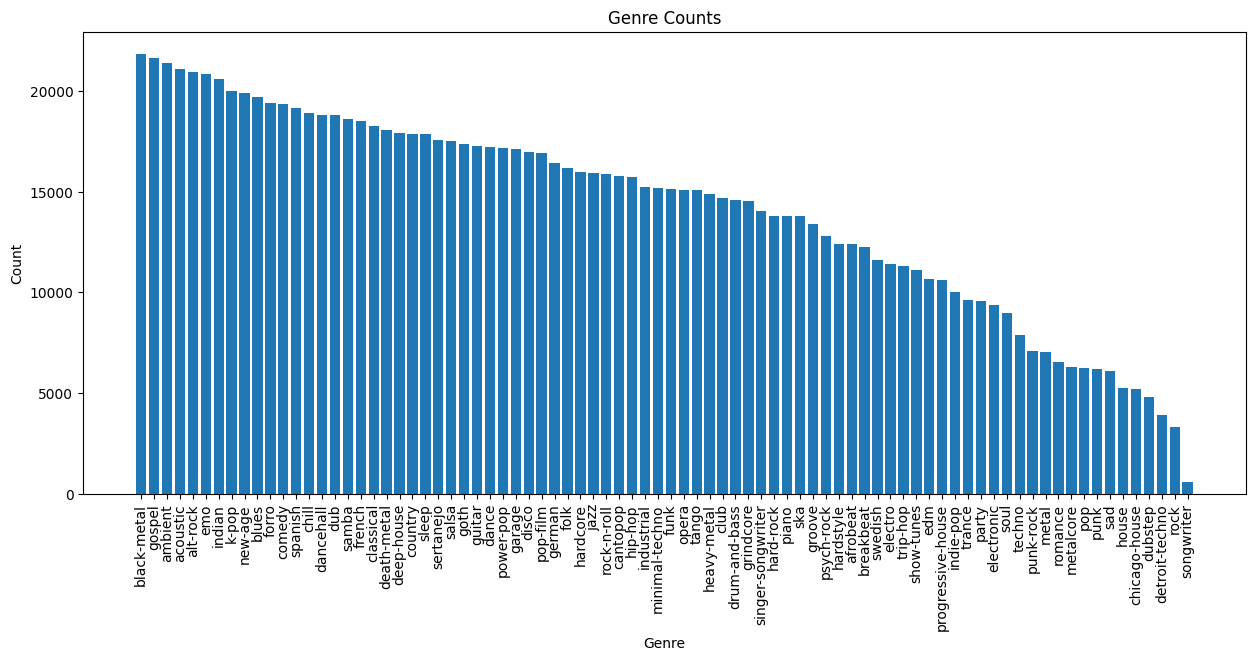

In [12]:
genre_counts = df['genre'].value_counts()
plt.figure(figsize=(15, 6))
plt.bar(genre_counts.index, genre_counts.values)
plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Genre Counts')
plt.xticks(rotation=90)
plt.show()

## Distribution of Popularity

The code creates a histogram to display the distribution of the "popularity" values in the dataset. It provides a visual representation of the frequency of different popularity levels, with the x-axis representing the popularity values and the y-axis representing the count of tracks falling within each popularity range.



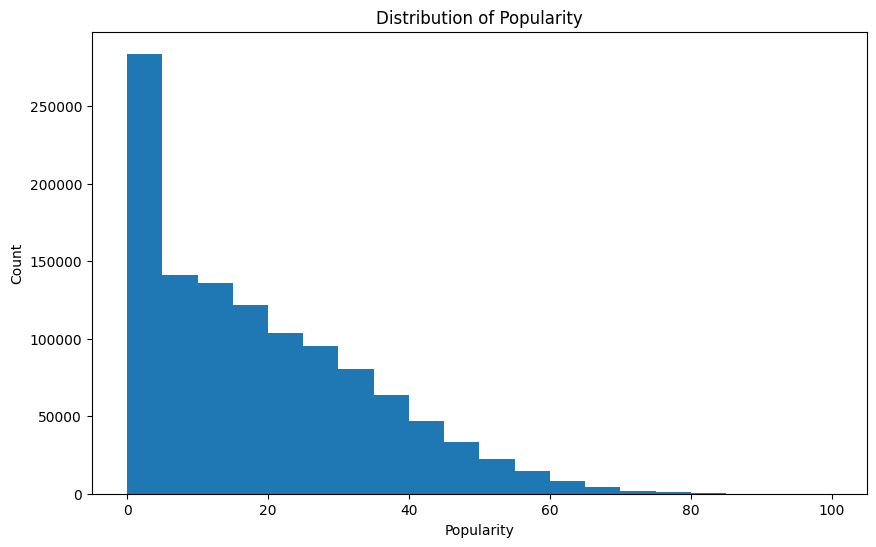

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=20)
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.title('Distribution of Popularity')
plt.show()

## Danceability vs Energy

The code creates a scatter plot to visualize the relationship between the "danceability" and "energy" attributes of the songs in the dataset. Each data point represents a song, with the x-axis representing the danceability and the y-axis representing the energy. The plot helps understand any potential correlation or patterns between these two attributes.



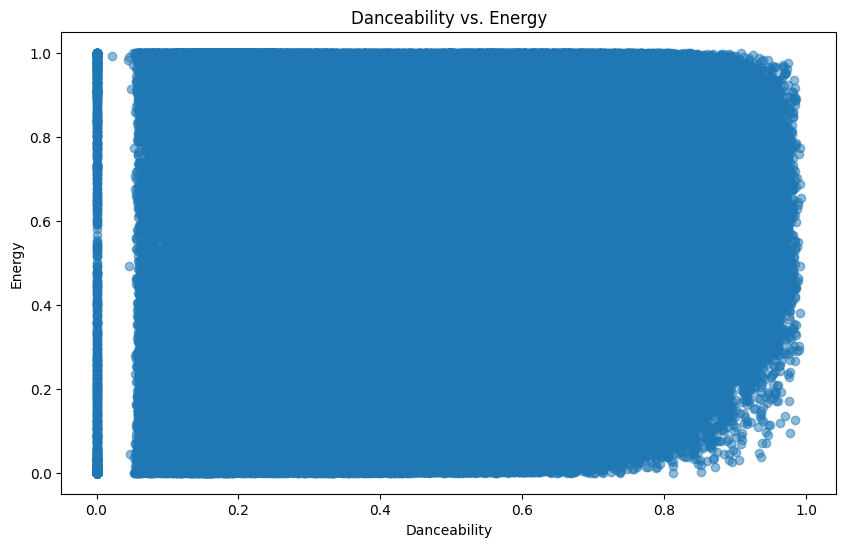

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(df['danceability'], df['energy'], alpha=0.5)
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.title('Danceability vs. Energy')
plt.show()

## Key Counts

The code calculates the count of songs for each musical key in the dataset and creates a bar plot to visualize the distribution. The x-axis represents the musical keys, the y-axis represents the count of songs, and each bar represents a unique key. The plot provides insights into the frequency of different musical keys in the dataset.






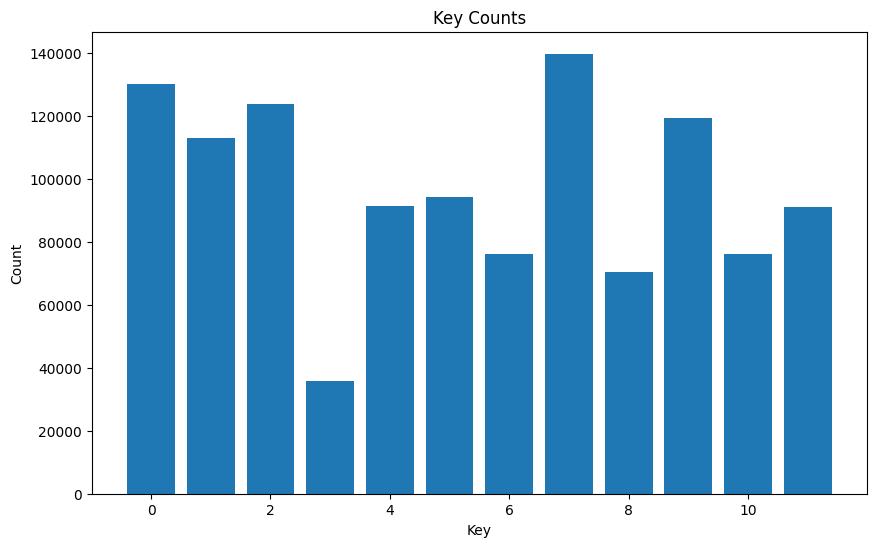

In [15]:
key_counts = df['key'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(key_counts.index, key_counts.values)
plt.xlabel('Key')
plt.ylabel('Count')
plt.title('Key Counts')
plt.show()

## Top Danceability by Genre

The code calculates the average danceability for each genre in the dataset and sorts them in descending order. It then creates a bar plot to visualize the top genres based on their average danceability. The x-axis represents the genres, the y-axis represents the average danceability, and each bar represents a genre. The plot helps identify the genres with the highest average danceability.






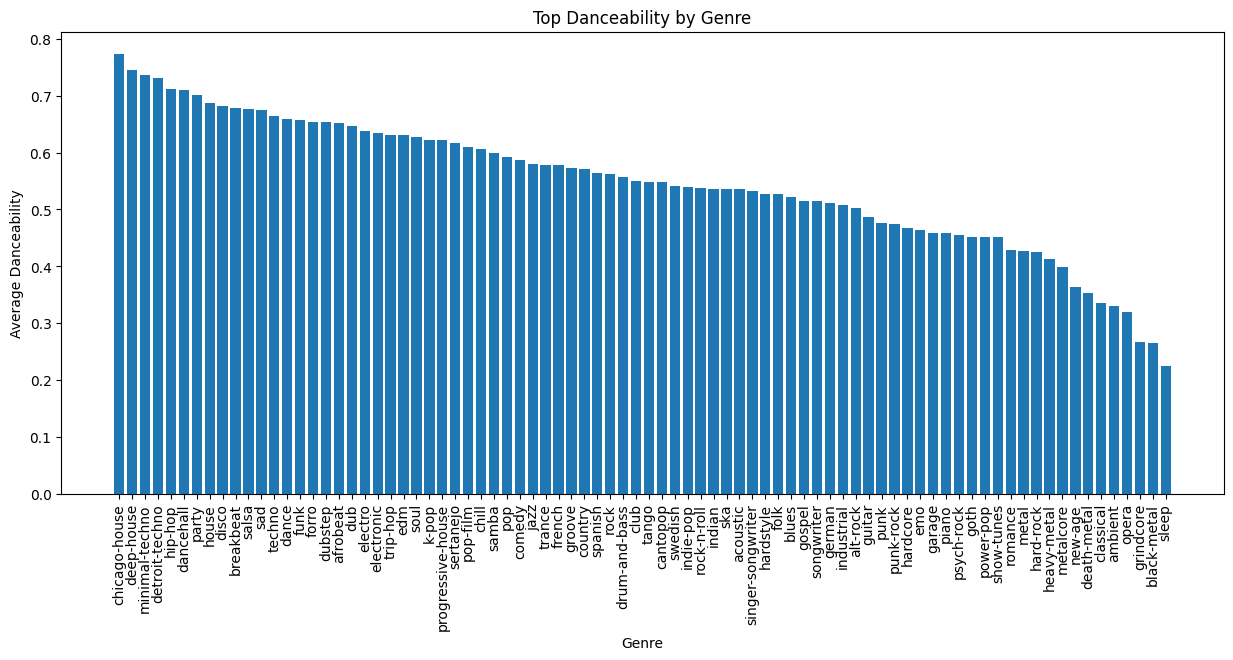

In [16]:
genre_danceability = df.groupby('genre')['danceability'].mean().sort_values(ascending=False)

plt.figure(figsize=(15, 6))
plt.bar(genre_danceability.index, genre_danceability.values)
plt.xlabel('Genre')
plt.ylabel('Average Danceability')
plt.title('Top Danceability by Genre')
plt.xticks(rotation=90)
plt.show()

## Top Energy by Genre

The code calculates the average energy for each genre in the dataset and sorts them in descending order. It then creates a bar plot to visualize the top genres based on their average energy. The x-axis represents the genres, the y-axis represents the average energy, and each bar represents a genre. The plot helps identify the genres with the highest average energy.






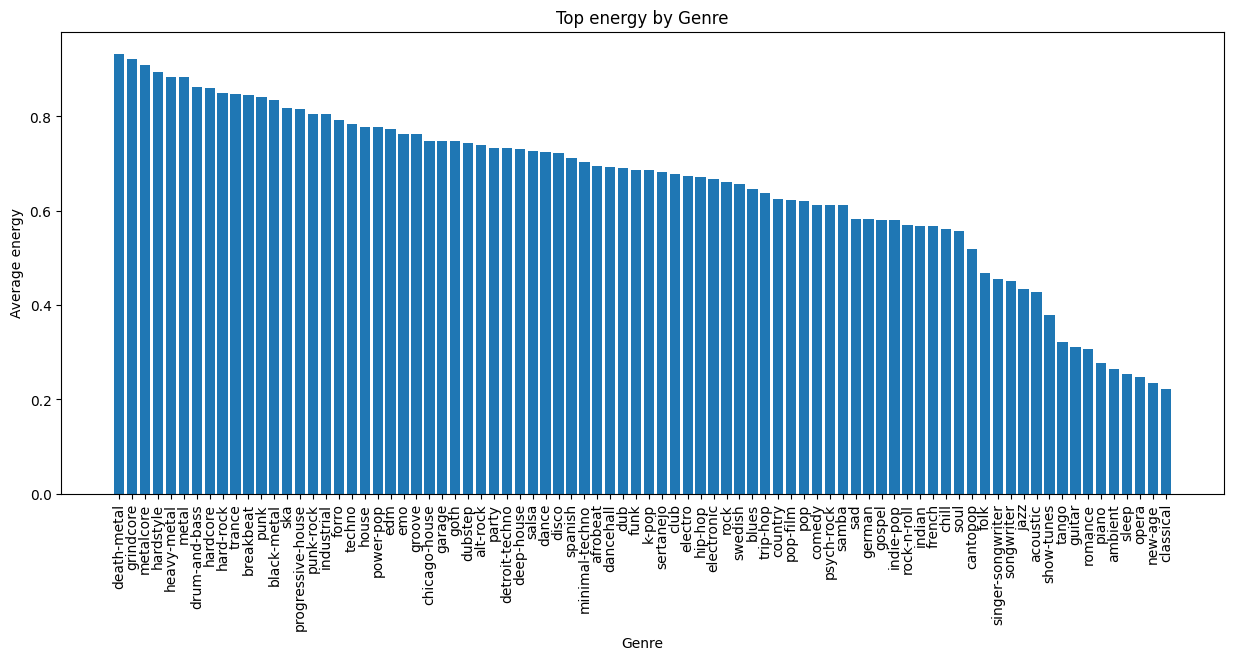

In [17]:
genre_danceability = df.groupby('genre')['energy'].mean().sort_values(ascending=False)

plt.figure(figsize=(15, 6))
plt.bar(genre_danceability.index, genre_danceability.values)
plt.xlabel('Genre')
plt.ylabel('Average energy')
plt.title('Top energy by Genre')
plt.xticks(rotation=90)
plt.show()

# Clustering Using K Means

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
# --- Schema Reconciliation: load from centralized data directory ---
_data_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "..", "data", "spotify_health_clustering")
_csv_path = os.path.join(_data_dir, "train.csv") if os.path.exists(os.path.join(_data_dir, "train.csv")) else "data.csv"
data = pd.read_csv(_csv_path)

# Column mapping: substitute dataset uses different column names
_col_map = {"artists": "artist_name", "track_genre": "genre"}
data = data.rename(columns={k: v for k, v in _col_map.items() if k in data.columns})
if "Unnamed: 0" in data.columns:
    data = data.drop(columns=["Unnamed: 0"])

print("Columns:", data.columns.tolist())
print("Shape:", data.shape)

In [20]:
features = data[['danceability', 'energy', 'key']]

The code applies standard scaling to the features in the dataset. It uses the StandardScaler from scikit-learn to transform the features so that they have zero mean and unit variance.






In [21]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

---
## Step 1 & 2: Clustering Pipeline (PyCaret)

Automated clustering pipeline with PyCaret:
- `setup()` → preprocessing & configuration
- `create_model()` → K-Means clustering
- `assign_model()` → assign cluster labels
- `plot_model()` → visualize clusters


In [ ]:
from pycaret.clustering import *

clust_setup = setup(data=df, normalize=True, session_id=42, verbose=False)

# Create K-Means model
kmeans_model = create_model('kmeans')
print(kmeans_model)


In [ ]:
# Assign cluster labels to data
clustered_df = assign_model(kmeans_model)
clustered_df.head()


In [ ]:
# Evaluate clustering
plot_model(kmeans_model, plot='elbow')


In [ ]:
# Silhouette plot
plot_model(kmeans_model, plot='silhouette')


In [ ]:
# Distribution plot
plot_model(kmeans_model, plot='distribution')